In [2]:
import glob
import math
from pathlib import Path
import pandas as pd
import numpy as np

In [170]:
from scipy import stats

In [3]:
import seaborn as sns
import matplotlib.colors as mcolors
import matplotlib.gridspec as gridspec
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D

In [4]:
from sklearn.metrics import roc_auc_score, roc_curve

In [138]:
def load_prediction(method, disease, study):
    """One score per sample for this method/disease/study, or None.

    'mean' is ens_prob: the members' probabilities averaged after being aligned
    on sample_id. Aligning on the id rather than on row order is the difference
    between an ensemble and a silently shuffled one -- the members are written
    by separate processes and nothing in the pipeline promises the same order.
    """
    spec = METHOD_SPEC[method]
    file_list = sorted((RESULT_BASE / spec["dir"] / f"{disease}_{study}").glob(spec["glob"]))
    if not file_list:
        return None

    if spec["agg"] == "first":
        pred = pd.read_csv(file_list[0])
        pred.attrs["n_files"] = 1
        pred.attrs["n_found"] = len(file_list)
        return pred

    frames = []
    for path in file_list:
        d = pd.read_csv(path)
        d["sample_id"] = d["sample_id"].astype(str)
        frames.append(d.set_index("sample_id")[["true_label", "prob"]])

    base = frames[0]
    probs = []
    for d in frames:
        s = d["prob"].reindex(base.index)
        if s.isna().any():
            raise ValueError(
                f"{method}/{disease}_{study}: members score different sample "
                f"sets; {int(s.isna().sum())} of {len(base)} samples missing "
                f"from {path.parent.name}")
        if not (d["true_label"].reindex(base.index) == base["true_label"]).all():
            raise ValueError(
                f"{method}/{disease}_{study}: members disagree about the labels")
        probs.append(s.to_numpy())

    pred = pd.DataFrame({"sample_id": base.index,
                         "true_label": base["true_label"].to_numpy(),
                         "prob": np.mean(probs, axis=0)})
    pred.attrs["n_files"] = len(frames)
    pred.attrs["n_found"] = len(file_list)
    return pred

## Leave one study out for each disease

In [51]:
metadata = pd.read_csv("../../data/metadata_disease_classification.tsv", sep="\t")

In [52]:
metadata.head(n=2)

,sample,study,diagnosis,group,age,sex,bmi,country,region,pcr_primers,platform,disease_name,title,disease_name_ab,host_body_mass_index,site,subject_id
0,DRR151663,PRJDB7456,control,0.0,NaN,NaN,NaN,Japan,V3-V4?,f(CTACGGGGGGCAGCAG) r(GGACTACNNGGGTATCTAAT),Illumina MiSeq,coronary artery disease,Effect of Resistant Starch on the Gut Microbio...,CAD,NaN,NaN,NaN
1,DRR151664,PRJDB7456,control,0.0,NaN,NaN,NaN,Japan,V3-V4?,f(CTACGGGGGGCAGCAG) r(GGACTACNNGGGTATCTAAT),Illumina MiSeq,coronary artery disease,Effect of Resistant Starch on the Gut Microbio...,CAD,NaN,NaN,NaN


In [174]:
run_list = pd.read_csv("run_leave_one_study_out_each_diease_list.tsv", sep="\t")

In [175]:
run_list.head()

,disease,study
0,AS,PRJCA007396
1,AS,SRP332779
2,ASD,PRJNA1103839
3,ASD,PRJNA578223
4,ASD,PRJNA932561


### AUC Performance of RF and Attention Models in IBD and CRC

In [176]:
METHOD_SPEC = {
    "SNEs": dict(dir="results_with_SNEs", glob="members/*/pred_test.csv", agg="mean"),
    "snes_shuffle":   dict(dir="results_with_shuffled_SNEs", glob="members/*/pred_test.csv", agg="mean"),
    "phyloe":   dict(dir="results_with_phylo_embed_PCA", glob="members/*/pred_test.csv", agg="mean"),
    "dnabert2":   dict(dir="results_with_dnabert2", glob="members/*/pred_test.csv", agg="mean"),
    "df_reduced_PCA":   dict(dir="results_with_pretain_df_reduced_PCA", glob="members/*/pred_test.csv", agg="mean"),
}

In [177]:
records = []

disease_type = ["CRC", "IBD"]
run_list_pick = run_list.loc[[i in disease_type for i in run_list.disease.values]]

for i in range(run_list_pick.shape[0]):

    d = run_list_pick.iloc[i, 0]
    s = run_list_pick.iloc[i, 1]

    preds = {
        "RF":             pd.read_csv(f"Data/disease_data/_results_with_rf/{d}_{s}/rf/pred_test.csv"),
        "RF_SNEs":         pd.read_csv(f"Data/disease_data/results_with_rf_embed/{d}_{s}/pred_prob.csv"),
        "Att_SNEs":       load_prediction("SNEs", d, s),
        "Att_SNEs_shuffle": load_prediction("snes_shuffle", d, s),
        "Att_PhyloE":     load_prediction("phyloe", d, s),
        "Att_DNABERT2":   load_prediction("dnabert2", d, s),
        "Att_df_reduced_PCA": load_prediction("df_reduced_PCA", d, s),
    }

    for method, pred in preds.items():
        records.append({
            "disease": d,
            "study": s,
            "model": "RF" if method.startswith("RF") else "Attention",
            "method": method,
            "auc": roc_auc_score(pred["true_label"], pred["prob"]),
        })

df = pd.DataFrame(records)

In [ ]:
def get_tab10_colors(n):
    cmap = plt.get_cmap("tab10")
    return [cmap(i % cmap.N) for i in range(n)]

fig, axes = plt.subplots(1, 2, figsize=(12, 3.5), dpi=450, sharey=True)

for ax, dis in zip(axes, ["CRC", "IBD"]):
    sub = df[df["disease"] == dis]
    methods = list(sub["method"].unique())

    studies_sorted = sorted(sub["study"].unique())
    palette = dict(zip(studies_sorted, get_tab10_colors(len(studies_sorted))))

    sns.boxplot(data=sub, x="method", y="auc", ax=ax, width=0.4,
                order=methods, boxprops=dict(alpha=0.4),
                medianprops=dict(color="black"))

    for study, g in sub.groupby("study"):
        g = g.set_index("method").loc[methods]
        ax.plot(range(len(methods)), g["auc"], ls="--",
                color=palette[study], alpha=0.5, lw=1)
        ax.scatter(range(len(methods)), g["auc"], color=palette[study],
                   edgecolor="k", s=40, zorder=3)

    ax.set_title(dis)
    ax.set_xlabel("")
    ax.set_ylabel("AUC")
    ax.set_xticklabels(methods, rotation=15, ha="right")

    # shaded background behind the RF-family columns (RF and RF_sne)
    i_rf = [k for k, m in enumerate(methods) if m in ("RF", "RF_SNEs")]
    ax.axvspan(min(i_rf) - 0.5, max(i_rf) + 0.5, color="grey", alpha=0.15, zorder=0)
    ax.axvline(max(i_rf) + 0.5, color="grey", lw=1, ls=":", alpha=0.6, zorder=0)

    # mean AUC annotation on top of each column
    ymax = sub["auc"].max()
    ax.set_ylim(bottom=0.45, top=ymax + 0.06)
    for k, m in enumerate(methods):
        mu = sub.loc[sub["method"] == m, "auc"].mean()
        ax.text(k, ymax + 0.025, f"{mu:.2f}", ha="center", va="center",
                fontsize=9, fontweight="bold")

    # horizontal lines: mean AUC of the "RF" column and the "Att_SNEs_shuffle" column
    mu_rf = sub.loc[sub["method"] == "RF", "auc"].mean()
    mu_shf = sub.loc[sub["method"] == "Att_SNEs_shuffle", "auc"].mean()

    ax.axhline(mu_rf, color="#d62728", lw=1.5, ls="-", alpha=0.8, zorder=2)
    ax.text(len(methods) - 0.5, mu_rf, f"RF {mu_rf:.2f}", color="#d62728",
            ha="right", va="bottom", fontsize=8)

    ax.axhline(mu_shf, color="#1f77b4", lw=1.5, ls="-", alpha=0.8, zorder=2)
    ax.text(len(methods) - 0.5, mu_shf, f"Att_SNEs_shuffle {mu_shf:.2f}",
            color="#1f77b4", ha="right", va="top", fontsize=8)

    handles = [Line2D([0], [0], marker="o", linestyle="--", lw=1,
                      markerfacecolor=palette[s], markeredgecolor="k",
                      color=palette[s], alpha=0.8, markersize=7, label=s)
               for s in studies_sorted]
    ax.legend(handles=handles, loc="upper center",
              bbox_to_anchor=(0.5, -0.28), ncol=min(len(studies_sorted), 4),
              fontsize=8, frameon=False)

plt.tight_layout()
plt.show()

/home/dongbiao/tmp/ipykernel_9167/4108053733.py:28: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(methods, rotation=15, ha="right")
/home/dongbiao/tmp/ipykernel_9167/4108053733.py:28: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(methods, rotation=15, ha="right")


### IBD and CRC of ROC plots comparing SNEs and RF.

  CRC_PRJDB11845           SNEs: 6 file(s), AUC 0.7808  RF: 1 file(s), AUC 0.7546
  CRC_PRJEB36789           SNEs: 6 file(s), AUC 0.9027  RF: 1 file(s), AUC 0.8928
  CRC_PRJEB6070            SNEs: 6 file(s), AUC 0.8249  RF: 1 file(s), AUC 0.8480
  CRC_PRJNA290926          SNEs: 6 file(s), AUC 0.7941  RF: 1 file(s), AUC 0.7753
  CRC_PRJNA318004          SNEs: 6 file(s), AUC 0.7618  RF: 1 file(s), AUC 0.7327
  CRC_PRJNA430990          SNEs: 6 file(s), AUC 0.7096  RF: 1 file(s), AUC 0.6906
  CRC_PRJNA824020          SNEs: 6 file(s), AUC 0.8263  RF: 1 file(s), AUC 0.5565
  IBD_PRJNA324147          SNEs: 7 file(s), AUC 0.7429  RF: 1 file(s), AUC 0.6849
  IBD_PRJNA368966          SNEs: 7 file(s), AUC 0.8514  RF: 1 file(s), AUC 0.6408
  IBD_PRJNA422193          SNEs: 7 file(s), AUC 0.8251  RF: 1 file(s), AUC 0.8249
  IBD_PRJNA431126          SNEs: 7 file(s), AUC 0.7398  RF: 1 file(s), AUC 0.6034
  IBD_PRJNA450340          SNEs: 7 file(s), AUC 0.8543  RF: 1 file(s), AUC 0.8867
  IBD_RISK_PRISM

/home/dongbiao/tmp/ipykernel_455936/1242078235.py:282: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout(pad=1.0)


ROC plots for all selected diseases have been generated individually.


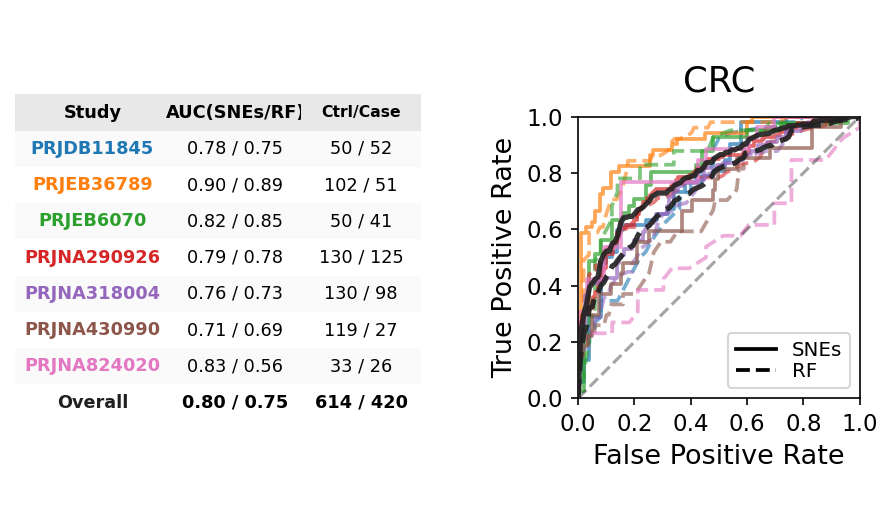

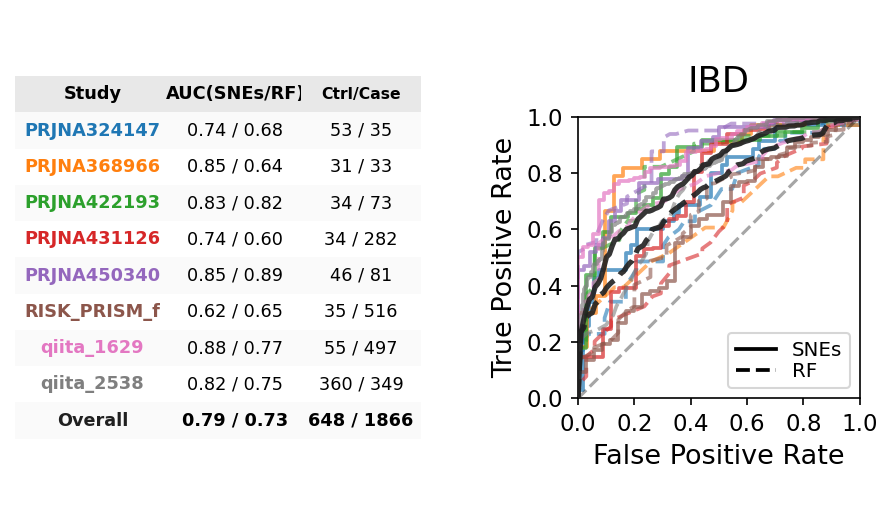

In [139]:
"""
ROC plots comparing SNEs and RF.

Layout follows the reference figure style:
    left  : summary table (Study / AUC(SNEs, RF) / Ctrl-Case counts)
    right : ROC curves, one color per study, solid = SNEs, dashed = RF,
            plus a black mean curve averaged over studies.

Data are read from the retrain prediction files:
    Data/disease_data/<method_dir>/<disease>_<study>/retrain/*/pred_test.csv
with columns: true_label, prob
"""
# --------------------------------------------------------------------------- #
# Configuration
# --------------------------------------------------------------------------- #
RESULT_BASE = Path("Data/disease_data")

DISEASE_COL, STUDY_COL = 0, 1
TARGET_DISEASES = ["IBD", "CRC"]

# Each method says where its predictions live below <base>/<dir>/<disease>_<study>/
# and how several files for one study become one score per sample.
#
#   SNEs  the leave-one-study-out run: one member per training cohort, combined
#         by 'ens_prob' -- the mean of the members' probabilities, which is the
#         combiner every SNEs number reported so far uses.
#   RF    unchanged: the retrain predictions, first file only, exactly as before.
METHOD_SPEC = {
    "SNEs": dict(dir="results_with_SNEs", glob="members/*/pred_test.csv", agg="mean"),
    "RF":   dict(dir="_results_with_rf", glob="rf/pred_test.csv", agg="first"),
}
METHOD_ORDER = ["SNEs", "RF"]
METHOD_STYLE = {"SNEs": "-", "RF": "--"}

DISEASE_ALIAS = {"IBD_feces": "IBD"}
plt.rcParams["axes.unicode_minus"] = False

# Line styling
study_line_linewidth = 1.8
study_line_alpha = {"SNEs": 0.70, "RF": 0.60}
mean_line_color = "#202020"
mean_line_linewidth = 2.5
mean_line_alpha = {"SNEs": 0.90, "RF": 0.90}
mean_line_zorder = 10

# Table styling
header_color = "#E8E8E8"
row_color_even = "#FAFAFA"
row_color_odd = "#FFFFFF"

single_plot_width = 7.0  # inches
single_plot_height = 4.2  # inches

FPR_COMMON = np.linspace(0, 1, 100)


# --------------------------------------------------------------------------- #
# Helpers
# --------------------------------------------------------------------------- #
def get_tab10_colors(n):
    cmap = plt.get_cmap("tab10")
    if n <= 0:
        return []
    return [cmap(i % cmap.N) for i in range(n)]


def load_prediction(method, disease, study):
    """One score per sample for this method/disease/study, or None.

    'mean' is ens_prob: the members' probabilities averaged after being aligned
    on sample_id. Aligning on the id rather than on row order is the difference
    between an ensemble and a silently shuffled one -- the members are written
    by separate processes and nothing in the pipeline promises the same order.
    """
    spec = METHOD_SPEC[method]
    file_list = sorted((RESULT_BASE / spec["dir"] / f"{disease}_{study}").glob(spec["glob"]))
    if not file_list:
        return None

    if spec["agg"] == "first":
        pred = pd.read_csv(file_list[0])
        pred.attrs["n_files"] = 1
        pred.attrs["n_found"] = len(file_list)
        return pred

    frames = []
    for path in file_list:
        d = pd.read_csv(path)
        d["sample_id"] = d["sample_id"].astype(str)
        frames.append(d.set_index("sample_id")[["true_label", "prob"]])

    base = frames[0]
    probs = []
    for d in frames:
        s = d["prob"].reindex(base.index)
        if s.isna().any():
            raise ValueError(
                f"{method}/{disease}_{study}: members score different sample "
                f"sets; {int(s.isna().sum())} of {len(base)} samples missing "
                f"from {path.parent.name}")
        if not (d["true_label"].reindex(base.index) == base["true_label"]).all():
            raise ValueError(
                f"{method}/{disease}_{study}: members disagree about the labels")
        probs.append(s.to_numpy())

    pred = pd.DataFrame({"sample_id": base.index,
                         "true_label": base["true_label"].to_numpy(),
                         "prob": np.mean(probs, axis=0)})
    pred.attrs["n_files"] = len(frames)
    pred.attrs["n_found"] = len(file_list)
    return pred


def roc_from_prediction(pred):
    """Return (fpr, tpr, auc) from a prediction table."""
    y_true = pred["true_label"].values
    y_score = pred["prob"].values
    fpr, tpr, _ = roc_curve(y_true, y_score)
    return fpr, tpr, roc_auc_score(y_true, y_score)


def count_labels(pred):
    """Return (n_control, n_case) from the true labels."""
    y_true = pd.Series(pred["true_label"].values)
    return int((y_true == 0).sum()), int((y_true == 1).sum())


# --------------------------------------------------------------------------- #
# collect results
# --------------------------------------------------------------------------- #
records = {}  # disease -> list of per-study dicts

for i in range(run_list.shape[0]):
    disease = str(run_list.iloc[i, DISEASE_COL])
    study = str(run_list.iloc[i, STUDY_COL])

    if TARGET_DISEASES is not None and disease not in TARGET_DISEASES:
        continue

    entry = {"study": study, "curves": {}, "aucs": {}, "n_ctrl": None, "n_case": None,
             "status": "ok"}

    for method in METHOD_ORDER:
        pred = load_prediction(method, disease, study)
        if pred is None:
            print(f"Warning: no pred_test.csv for {method} / {disease} / {study}")
            entry["status"] = "missing"
            continue
        try:
            fpr, tpr, auc_val = roc_from_prediction(pred)
        except Exception as exc:  # e.g. a single-class test split
            print(f"Error computing ROC for {method} / {disease} / {study}: {exc}")
            entry["status"] = "error"
            continue
        entry["curves"][method] = (fpr, tpr)
        entry["aucs"][method] = auc_val
        entry.setdefault("n_files", {})[method] = pred.attrs.get("n_files", 1)
        if entry["n_ctrl"] is None:
            entry["n_ctrl"], entry["n_case"] = count_labels(pred)
            
    if entry["status"] == "ok":
        print(f"  {disease}_{study:<20} "
              + "  ".join(f"{m}: {entry['n_files'].get(m, 0)} file(s), "
                          f"AUC {entry['aucs'].get(m, float('nan')):.4f}"
                          for m in METHOD_ORDER))
    records.setdefault(disease, []).append(entry)


# --------------------------------------------------------------------------- #
# Plot one figure per disease
# --------------------------------------------------------------------------- #
# FIGURE_DIR.mkdir(parents=True, exist_ok=True)
for disease in sorted(records.keys()):
    entries = sorted(records[disease], key=lambda e: e["study"])
    colors = get_tab10_colors(len(entries))

    fig = plt.figure(figsize=(single_plot_width, single_plot_height), dpi=150)
    gs = gridspec.GridSpec(1, 2, figure=fig, wspace=0.6, width_ratios=[0.55, 0.45])
    ax_table = fig.add_subplot(gs[0, 0])
    ax_table.axis("off")
    ax_roc = fig.add_subplot(gs[0, 1])

    interp_tpr = {method: [] for method in METHOD_ORDER}
    aucs_for_mean = {method: [] for method in METHOD_ORDER}
    total_ctrl, total_case = 0, 0
    table_rows = []

    for row_idx, entry in enumerate(entries):
        color = colors[row_idx]
        study = entry["study"]

        for method in METHOD_ORDER:
            if method not in entry["curves"]:
                continue
            fpr, tpr = entry["curves"][method]
            ax_roc.plot(fpr, tpr, color=color, linestyle=METHOD_STYLE[method],
                        linewidth=study_line_linewidth, alpha=study_line_alpha[method])
            interp_tpr[method].append(np.interp(FPR_COMMON, fpr, tpr))
            aucs_for_mean[method].append(entry["aucs"][method])

        if entry["n_ctrl"] is not None:
            counts_text = f"{entry['n_ctrl']} / {entry['n_case']}"
            total_ctrl += entry["n_ctrl"]
            total_case += entry["n_case"]
        else:
            counts_text = "N/A"

        if len(entry["aucs"]) == len(METHOD_ORDER):
            auc_text = " / ".join(f"{entry['aucs'][m]:.2f}" for m in METHOD_ORDER)
            name = study
        else:
            auc_text = "N/A"
            suffix = "Missing" if entry["status"] == "missing" else "Error"
            name = f"{study} ({suffix})"

        table_rows.append({"color": color if auc_text != "N/A" else "grey",
                           "name": name, "auc_text": auc_text,
                           "counts": counts_text, "is_mean": False,
                           "row_idx": row_idx})

    # Mean curves and overall row
    if all(len(interp_tpr[m]) > 0 for m in METHOD_ORDER):
        for method in METHOD_ORDER:
            mean_tpr = np.mean(interp_tpr[method], axis=0)
            mean_tpr[0], mean_tpr[-1] = 0.0, 1.0
            ax_roc.plot(FPR_COMMON, mean_tpr, color=mean_line_color,
                        linestyle=METHOD_STYLE[method], linewidth=mean_line_linewidth,
                        alpha=mean_line_alpha[method], zorder=mean_line_zorder)

        mean_auc_text = " / ".join(f"{np.mean(aucs_for_mean[m]):.2f}" for m in METHOD_ORDER)
        table_rows.append({"color": mean_line_color, "name": "Overall",
                           "auc_text": mean_auc_text,
                           "counts": f"{total_ctrl} / {total_case}",
                           "is_mean": True, "row_idx": len(entries)})

    # ROC axis cosmetics
    ax_roc.plot([0, 1], [0, 1], "k--", alpha=0.35)
    ax_roc.set_xlim([0, 1])
    ax_roc.set_ylim([0, 1])
    ticks = np.arange(0, 1.01, 0.2)
    ax_roc.set_xticks(ticks)
    ax_roc.set_yticks(ticks)
    ax_roc.set_aspect("equal", adjustable="box")
    ax_roc.set_title(DISEASE_ALIAS.get(disease, disease), fontsize=17, pad=12)
    ax_roc.set_xlabel("False Positive Rate", fontsize=13)
    ax_roc.set_ylabel("True Positive Rate", fontsize=13)
    ax_roc.tick_params(axis="both", which="major", labelsize=11)

    legend_elements = [Line2D([0], [0], color="black", lw=1.8,
                              linestyle=METHOD_STYLE[m], label=m) for m in METHOD_ORDER]
    ax_roc.legend(handles=legend_elements, loc="lower right", fontsize=9.5, labelspacing=0.1)

    # Table
    if table_rows:
        col_labels = ["Study", "AUC(SNEs/RF)", "Ctrl/Case"]
        cell_text = [[r["name"], r["auc_text"], r["counts"]] for r in table_rows]

        the_table = ax_table.table(cellText=cell_text, colLabels=col_labels, loc="center",
                                   colWidths=[0.45, 0.38, 0.35])
        the_table.auto_set_font_size(False)
        the_table.set_fontsize(8.5)
        the_table.scale(1, 1.45)

        for (row, col), cell in the_table.get_celld().items():
            cell.set_linewidth(0)
            cell.set_text_props(ha="center", va="center")
            if row == 0:
                cell.set_facecolor(header_color)
                cell.set_text_props(weight="bold", color="black")
                if col == 2:
                    cell.set_fontsize(7.5)
            else:
                row_data = table_rows[row - 1]
                cell.set_facecolor(row_color_even if row_data["row_idx"] % 2 == 0
                                   else row_color_odd)
                if col == 0:
                    cell.get_text().set_color(row_data["color"])
                    cell.get_text().set_weight("bold")
                if row_data["is_mean"]:
                    cell.get_text().set_weight("bold")

    fig.tight_layout(pad=1.0)

    # out_name = f"roc_plot_{DISEASE_ALIAS.get(disease, disease)}.png"
    # try:
    #     fig.savefig(FIGURE_DIR / out_name, bbox_inches="tight", dpi=300, facecolor="white")
    #     print(f"Figure '{out_name}' has been saved.")
    # except Exception as exc:
    #     print(f"Saving figure '{out_name}' encountered an error: {exc}")

    # plt.close(fig)
fig
print("ROC plots for all selected diseases have been generated individually.")

### Leave one dataset out

In [63]:
run_list = pd.read_csv("run_leave_one_study_out.tsv", sep="\t")
run_list.head(n=2)

,study_group,left_out_study
0,all_studies,PRJCA000673
1,all_studies,PRJCA007396


In [64]:
def load_prediction_lodo(file_path):
    """One score per sample for this method/disease/study, or None.

    'mean' is ens_prob: the members' probabilities averaged after being aligned
    on sample_id. Aligning on the id rather than on row order is the difference
    between an ensemble and a silently shuffled one -- the members are written
    by separate processes and nothing in the pipeline promises the same order.
    """
    file_pattern = f'{file_path}/*/pred_test.csv'
    file_list = glob.glob(file_pattern)

    frames = []
    for path in file_list:
        d = pd.read_csv(path)
        d["sample_id"] = d["sample_id"].astype(str)
        frames.append(d.set_index("sample_id")[["true_label", "prob"]])

    base = frames[0]
    probs = []
    for d in frames:
        s = d["prob"].reindex(base.index)
        if s.isna().any():
            raise ValueError(
                f"{method}/{disease}_{study}: members score different sample "
                f"sets; {int(s.isna().sum())} of {len(base)} samples missing "
                f"from {path.parent.name}")
        if not (d["true_label"].reindex(base.index) == base["true_label"]).all():
            raise ValueError(
                f"{method}/{disease}_{study}: members disagree about the labels")
        probs.append(s.to_numpy())

    pred = pd.DataFrame({"sample_id": base.index,
                         "true_label": base["true_label"].to_numpy(),
                         "prob": np.mean(probs, axis=0)})
    pred.attrs["n_files"] = len(frames)
    pred.attrs["n_found"] = len(file_list)
    return pred

In [65]:
auc_rf = []
auc_snes = []

for i in range(run_list.shape[0]):
    ### rf
    pred = pd.read_csv(f"Data/loo_all_studies/_results_with_rf/{run_list.iloc[i,1]}/rf/pred_test.csv")
    auc_rf.append(roc_auc_score(pred['true_label'].values, pred["prob"].values))

    ### snes
    pred = load_prediction_lodo(f"Data/loo_all_studies/results_with_SNEs/{run_list.iloc[i,1]}/members")
    auc_snes.append(roc_auc_score(pred['true_label'].values, pred["prob"].values))
    
auc_res = run_list.copy()
auc_res["auc_rf"] = auc_rf
auc_res["auc_snes"] = auc_snes

In [66]:
auc_res.head(n=2)

,study_group,left_out_study,auc_rf,auc_snes
0,all_studies,PRJCA000673,0.629717,0.689858
1,all_studies,PRJCA007396,0.587121,0.679924


In [68]:
auc_res['delta'] = auc_res.auc_rf.values - auc_res.auc_snes.values

In [70]:
auc_res.sort_values("delta")

,study_group,left_out_study,auc_rf,auc_snes,delta
4,all_studies,PRJDB7456,0.525758,0.800000,-0.274242
33,all_studies,PRJNA646010,0.428922,0.664216,-0.235294
42,all_studies,PRJNA819279,0.361905,0.576190,-0.214286
12,all_studies,PRJEB30615,0.611161,0.757484,-0.146323
41,all_studies,PRJNA807473,0.656729,0.791393,-0.134664
51,all_studies,SRP332779,0.574306,0.685417,-0.111111
1,all_studies,PRJCA007396,0.587121,0.679924,-0.092803
21,all_studies,PRJNA290926,0.570677,0.662831,-0.092154
40,all_studies,PRJNA807457,0.561250,0.652500,-0.091250
19,all_studies,PRJNA1103839,0.415054,0.504301,-0.089247


     study disease_name_ab
PRJEB11419              OB
PRJEB11419             IBS
PRJEB11419              BD
PRJEB11419            T2DM
Mean AUC (Random Forest): 0.628
Mean AUC (SNES):          0.647


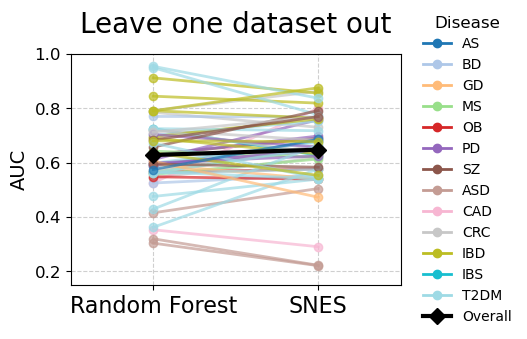

In [67]:
# ---------------- 1. Load data ----------------
# If auc_res / metadata are already in memory, replace the two reads below with:
#   df = auc_res.copy()
#   meta = metadata.copy()

df = auc_res
meta = metadata


required_columns = ['left_out_study', 'auc_rf', 'auc_snes']
missing_cols = [col for col in required_columns if col not in df.columns]
if missing_cols:
    print(f"Error: auc table is missing columns: {', '.join(missing_cols)}")
    exit()

meta_required = ['study', 'disease_name_ab']
missing_meta = [col for col in meta_required if col not in meta.columns]
if missing_meta:
    print(f"Error: metadata is missing columns: {', '.join(missing_meta)}")
    exit()

# ---------------- 2. Map study -> disease ----------------
# metadata has one row per sample, keep unique study / disease pairs only
study2disease = (
    meta[['study', 'disease_name_ab']]
    .dropna()
    .astype(str)
    .drop_duplicates()
)

# Warn if one study maps to several diseases, then keep the first one
dup_studies = study2disease['study'].duplicated(keep=False)
if dup_studies.any():
    print("Warning: these studies map to more than one disease, keeping the first:")
    print(study2disease[dup_studies].sort_values('study').to_string(index=False))
    study2disease = study2disease.drop_duplicates(subset='study', keep='first')

df = df.loc[:, ~df.columns.duplicated()].copy()
df['left_out_study'] = df['left_out_study'].astype(str)
df = df.merge(
    study2disease.rename(columns={'study': 'left_out_study'}),
    on='left_out_study',
    how='left'
)

unmatched = df.loc[df['disease_name_ab'].isna(), 'left_out_study'].tolist()
if unmatched:
    print(f"Warning: no disease found in metadata for: {', '.join(unmatched)}")

df['disease_name_ab'] = df['disease_name_ab'].fillna('Unknown').astype(str)
df['disease_name_ab'] = df['disease_name_ab'].replace('IBD_feces', 'IBD')
df = df.dropna(subset=['auc_rf', 'auc_snes'])

# Sort diseases by name length, then alphabetically
sorted_unique_diseases = sorted(
    df['disease_name_ab'].unique(),
    key=lambda x: (len(x), x)
)

# ---------------- 3. Colors ----------------
base_colors = list(mcolors.TABLEAU_COLORS.values())
if len(sorted_unique_diseases) > len(base_colors):
    cmap = plt.get_cmap('tab20', len(sorted_unique_diseases))
    colors_to_use = [cmap(i) for i in range(len(sorted_unique_diseases))]
else:
    colors_to_use = base_colors
color_map = {d: colors_to_use[i % len(colors_to_use)]
             for i, d in enumerate(sorted_unique_diseases)}

# ---------------- 4. Plot ----------------
fig, ax = plt.subplots(figsize=(6, 3))
fig.subplots_adjust(right=0.70, left=0.15)

model_positions = [0, 1]
xlim_range = (-0.5, 1.5)
marker_style = 'o'
marker_size = 6
line_linewidth = 2
mean_line_linewidth = 3
mean_marker_size = 8

for _, row_data in df.iterrows():
    ax.plot(
        model_positions,
        [row_data['auc_rf'], row_data['auc_snes']],
        color=color_map.get(row_data['disease_name_ab'], 'gray'),
        alpha=0.7,
        marker=marker_style,
        markersize=marker_size,
        linewidth=line_linewidth,
        linestyle='-'
    )

mean_rf = df['auc_rf'].mean()
mean_snes = df['auc_snes'].mean()
print(f"Mean AUC (Random Forest): {mean_rf:.3f}")
print(f"Mean AUC (SNES):          {mean_snes:.3f}")

mean_line_plot = ax.plot(
    model_positions,
    [mean_rf, mean_snes],
    color='black',
    linestyle='-',
    linewidth=mean_line_linewidth,
    marker='D',
    markersize=mean_marker_size,
    label='Overall',
    zorder=100
)[0]

# ---------------- 5. Axes ----------------
ax.grid(True, linestyle='--', alpha=0.6)
ax.set_xlim(xlim_range)
ax.set_ylim(0.15, 1.0)
ax.set_title('Leave one dataset out', fontsize=20, pad=15)
ax.set_xticks(model_positions)
ax.set_xticklabels(['Random Forest', 'SNES'], fontsize=16)
ax.set_ylabel('AUC', fontsize=14)
for label in ax.get_yticklabels():
    label.set_fontsize(12)

# ---------------- 6. Legend ----------------
legend_handles = [
    Line2D([0], [0], color=color_map[d], lw=line_linewidth, label=d,
           marker=marker_style, markersize=marker_size, linestyle='-')
    for d in sorted_unique_diseases
]
legend_handles.append(mean_line_plot)

legend_params = {
    'bbox_to_anchor': (1.03, 0.5),
    'loc': 'center left',
    'ncol': 1,
    'fontsize': 10,
    'title': 'Disease',
    'title_fontsize': 12,
    'frameon': False
}
ax.legend(handles=legend_handles, **legend_params)


plt.show()
print(f"Plot saved as {output_filename}")

### Leave one disease out

In [132]:
run_list = pd.read_csv("run_leave_one_disease_out.tsv", sep="\t")
run_list.head(n=2)

,disease_group,left_out_disease
0,all_disease,AS
1,all_disease,ASD


In [166]:
auc_rf = []
auc_snes = []

for i in range(run_list.shape[0]):
    ### rf
    pred = pd.read_csv(f"Data/loo_all_diseases/_results_with_rf//{run_list.iloc[i,1]}/rf/pred_test.csv")
    auc_rf.append(roc_auc_score(pred['true_label'].values, pred["prob"].values))

    ### snes
    pred = pred = load_prediction_lodo(f"Data/loo_all_diseases/results_with_SNEs/{run_list.iloc[i,1]}/members")
    auc_snes.append(roc_auc_score(pred['true_label'].values, pred["prob"].values))
auc_res = run_list.copy()
auc_res["auc_rf"] = auc_rf
auc_res["auc_snes"] = auc_snes

In [167]:
auc_res

,disease_group,left_out_disease,auc_rf,auc_snes
0,all_disease,AS,0.591534,0.629365
1,all_disease,ASD,0.340799,0.383065
2,all_disease,BD,0.639930,0.715834
3,all_disease,CAD,0.509831,0.610103
4,all_disease,CRC,0.533244,0.587781
5,all_disease,GD,0.624897,0.555247
6,all_disease,IBD,0.701238,0.740693
7,all_disease,IBS,0.599048,0.586203
8,all_disease,MS,0.547211,0.606844
9,all_disease,OB,0.529911,0.666792


Paired t-test (SNES vs RF): n = 13, t(12) = 3.464, P = 0.00468, mean diff = +0.050, Cohen's dz = 0.96
Wilcoxon signed-rank: W = 10.0, P = 0.0105
Mean AUC (Random Forest): 0.564
Mean AUC (SNES):          0.614


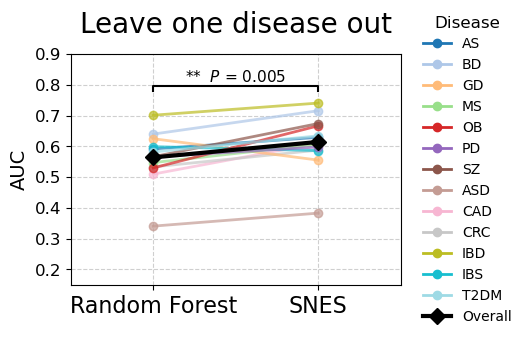

In [173]:
# ---------------- 1. Check ----------------
df = auc_res
required_columns = ['left_out_disease', 'auc_rf', 'auc_snes']
missing_cols = [col for col in required_columns if col not in df.columns]
if missing_cols:
    raise ValueError(f"table is missing columns: {', '.join(missing_cols)}")

# ---------------- 2. Prepare ----------------
df = df.loc[:, ~df.columns.duplicated()].copy()
df['left_out_disease'] = df['left_out_disease'].fillna('Unknown').astype(str)
df['left_out_disease'] = df['left_out_disease'].replace('IBD_feces', 'IBD')
df = df.dropna(subset=['auc_rf', 'auc_snes'])

sorted_unique_diseases = sorted(df['left_out_disease'].unique(),
                                key=lambda x: (len(x), x))

# ---------------- 3. Colors ----------------
base_colors = list(mcolors.TABLEAU_COLORS.values())
if len(sorted_unique_diseases) > len(base_colors):
    cmap = plt.get_cmap('tab20', len(sorted_unique_diseases))
    colors_to_use = [cmap(i) for i in range(len(sorted_unique_diseases))]
else:
    colors_to_use = base_colors
color_map = {d: colors_to_use[i % len(colors_to_use)]
             for i, d in enumerate(sorted_unique_diseases)}

# ---------------- 4. Paired t-test (SNES vs RF) ----------------
paired = df[['auc_rf', 'auc_snes']].dropna()
n_pairs = len(paired)
t_stat, p_val = stats.ttest_rel(paired['auc_snes'], paired['auc_rf'])
diff = paired['auc_snes'] - paired['auc_rf']
cohen_dz = diff.mean() / diff.std(ddof=1)

w_stat, w_p = stats.wilcoxon(paired['auc_snes'], paired['auc_rf'])

print(f"Paired t-test (SNES vs RF): n = {n_pairs}, t({n_pairs-1}) = {t_stat:.3f}, "
      f"P = {p_val:.3g}, mean diff = {diff.mean():+.3f}, Cohen's dz = {cohen_dz:.2f}")
print(f"Wilcoxon signed-rank: W = {w_stat:.1f}, P = {w_p:.3g}")


def format_p(p):
    if p < 1e-4:
        exp = int(f"{p:e}".split('e')[1])
        mant = float(f"{p:e}".split('e')[0])
        return rf"$\mathit{{P}}$ = {mant:.1f} $\times$ 10$^{{{exp}}}$"
    if p < 0.001:
        return r"$\mathit{P}$ < 0.001"
    return rf"$\mathit{{P}}$ = {p:.3f}"


if   p_val < 0.001: star = '***'
elif p_val < 0.01:  star = '**'
elif p_val < 0.05:  star = '*'
else:               star = 'n.s.'

p_label = format_p(p_val)

# ---------------- 5. Plot ----------------
fig, ax = plt.subplots(figsize=(6, 3))
fig.subplots_adjust(right=0.70, left=0.15)

model_positions = [0, 1]
marker_style, marker_size = 'o', 6
line_linewidth = 2

for _, row_data in df.iterrows():
    ax.plot(model_positions,
            [row_data['auc_rf'], row_data['auc_snes']],
            color=color_map.get(row_data['left_out_disease'], 'gray'),
            alpha=0.7, marker=marker_style, markersize=marker_size,
            linewidth=line_linewidth, linestyle='-')

mean_rf = df['auc_rf'].mean()
mean_snes = df['auc_snes'].mean()
print(f"Mean AUC (Random Forest): {mean_rf:.3f}")
print(f"Mean AUC (SNES):          {mean_snes:.3f}")

mean_line_plot = ax.plot(model_positions, [mean_rf, mean_snes],
                         color='black', linestyle='-', linewidth=3,
                         marker='D', markersize=8,
                         label='Overall', zorder=100)[0]

# ---------------- 6. Significance annotation ----------------
y_top = max(df['auc_rf'].max(), df['auc_snes'].max())
bar_y, h = y_top + 0.04, 0.015
ax.plot([0, 0, 1, 1], [bar_y, bar_y + h, bar_y + h, bar_y], lw=1.5, c='black')
ax.text(0.5, bar_y + h + 0.005,
        f"{star}  {p_label}",
        ha='center', va='bottom', fontsize=11)
# ---------------- 7. Axes ----------------
ax.grid(True, linestyle='--', alpha=0.6)
ax.set_xlim(-0.5, 1.5)
ax.set_ylim(0.15, min(1.10, bar_y + 0.12))
ax.set_title('Leave one disease out', fontsize=20, pad=15)
ax.set_xticks(model_positions)
ax.set_xticklabels(['Random Forest', 'SNES'], fontsize=16)
ax.set_ylabel('AUC', fontsize=14)
for label in ax.get_yticklabels():
    label.set_fontsize(12)

# ---------------- 8. Legend ----------------
legend_handles = [
    Line2D([0], [0], color=color_map[d], lw=line_linewidth, label=d,
           marker=marker_style, markersize=marker_size, linestyle='-')
    for d in sorted_unique_diseases
]
legend_handles.append(mean_line_plot)
ax.legend(handles=legend_handles,
          bbox_to_anchor=(1.03, 0.5), loc='center left', ncol=1,
          fontsize=10, title='Disease', title_fontsize=12, frameon=False)

# plt.savefig('leave_one_disease_out.pdf', bbox_inches='tight', dpi=300)
plt.show()

In [169]:
from scipy import stats
diff = df['auc_snes'] - df['auc_rf']

t_stat, p_value = stats.ttest_rel(df['auc_snes'], df['auc_rf'])

cohens_d = diff.mean() / diff.std(ddof=1)

print(f"Mean AUC (Random Forest): {df['auc_rf'].mean():.3f}")
print(f"Mean AUC (SNES):          {df['auc_snes'].mean():.3f}")
print(f"Mean paired difference (SNES - RF): {diff.mean():.3f}")
print(f"Paired t-test: t({len(diff)-1}) = {t_stat:.3f}, p = {p_value:.4g}")
print(f"Cohen's d: {cohens_d:.3f}")

Mean AUC (Random Forest): 0.564
Mean AUC (SNES):          0.614
Mean paired difference (SNES - RF): 0.050
Paired t-test: t(12) = 3.464, p = 0.004679
Cohen's d: 0.961


### ROC plots comparing SNEs and RF other diseases

fold                                       SNEs (layout, n, AUC)           RF (layout, n, AUC)
----------------------------------------------------------------------------------------------
AS_PRJCA007396                           inner,   5,      0.7027          rf,   1,      0.4773
AS_SRP332779                             inner,   5,      0.7333          rf,   1,      0.6913
  [warn] SNEs/ASD_PRJNA1103839: predictions under both 'members' and 'inner'; using 'members'
ASD_PRJNA1103839                       members,   2,      0.4871          rf,   1,      0.5559
  [warn] SNEs/ASD_PRJNA578223: predictions under both 'members' and 'inner'; using 'members'
ASD_PRJNA578223                        members,   2,      0.7925          rf,   1,      0.5744
  [warn] SNEs/ASD_PRJNA932561: predictions under both 'members' and 'inner'; using 'members'
ASD_PRJNA932561                        members,   2,      0.7819          rf,   1,      0.6197
  [warn] SNEs/BD_PRJEB11419: predictions under both 'me

/home/dongbiao/tmp/ipykernel_9167/3219220161.py:501: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout(pad=0.5)


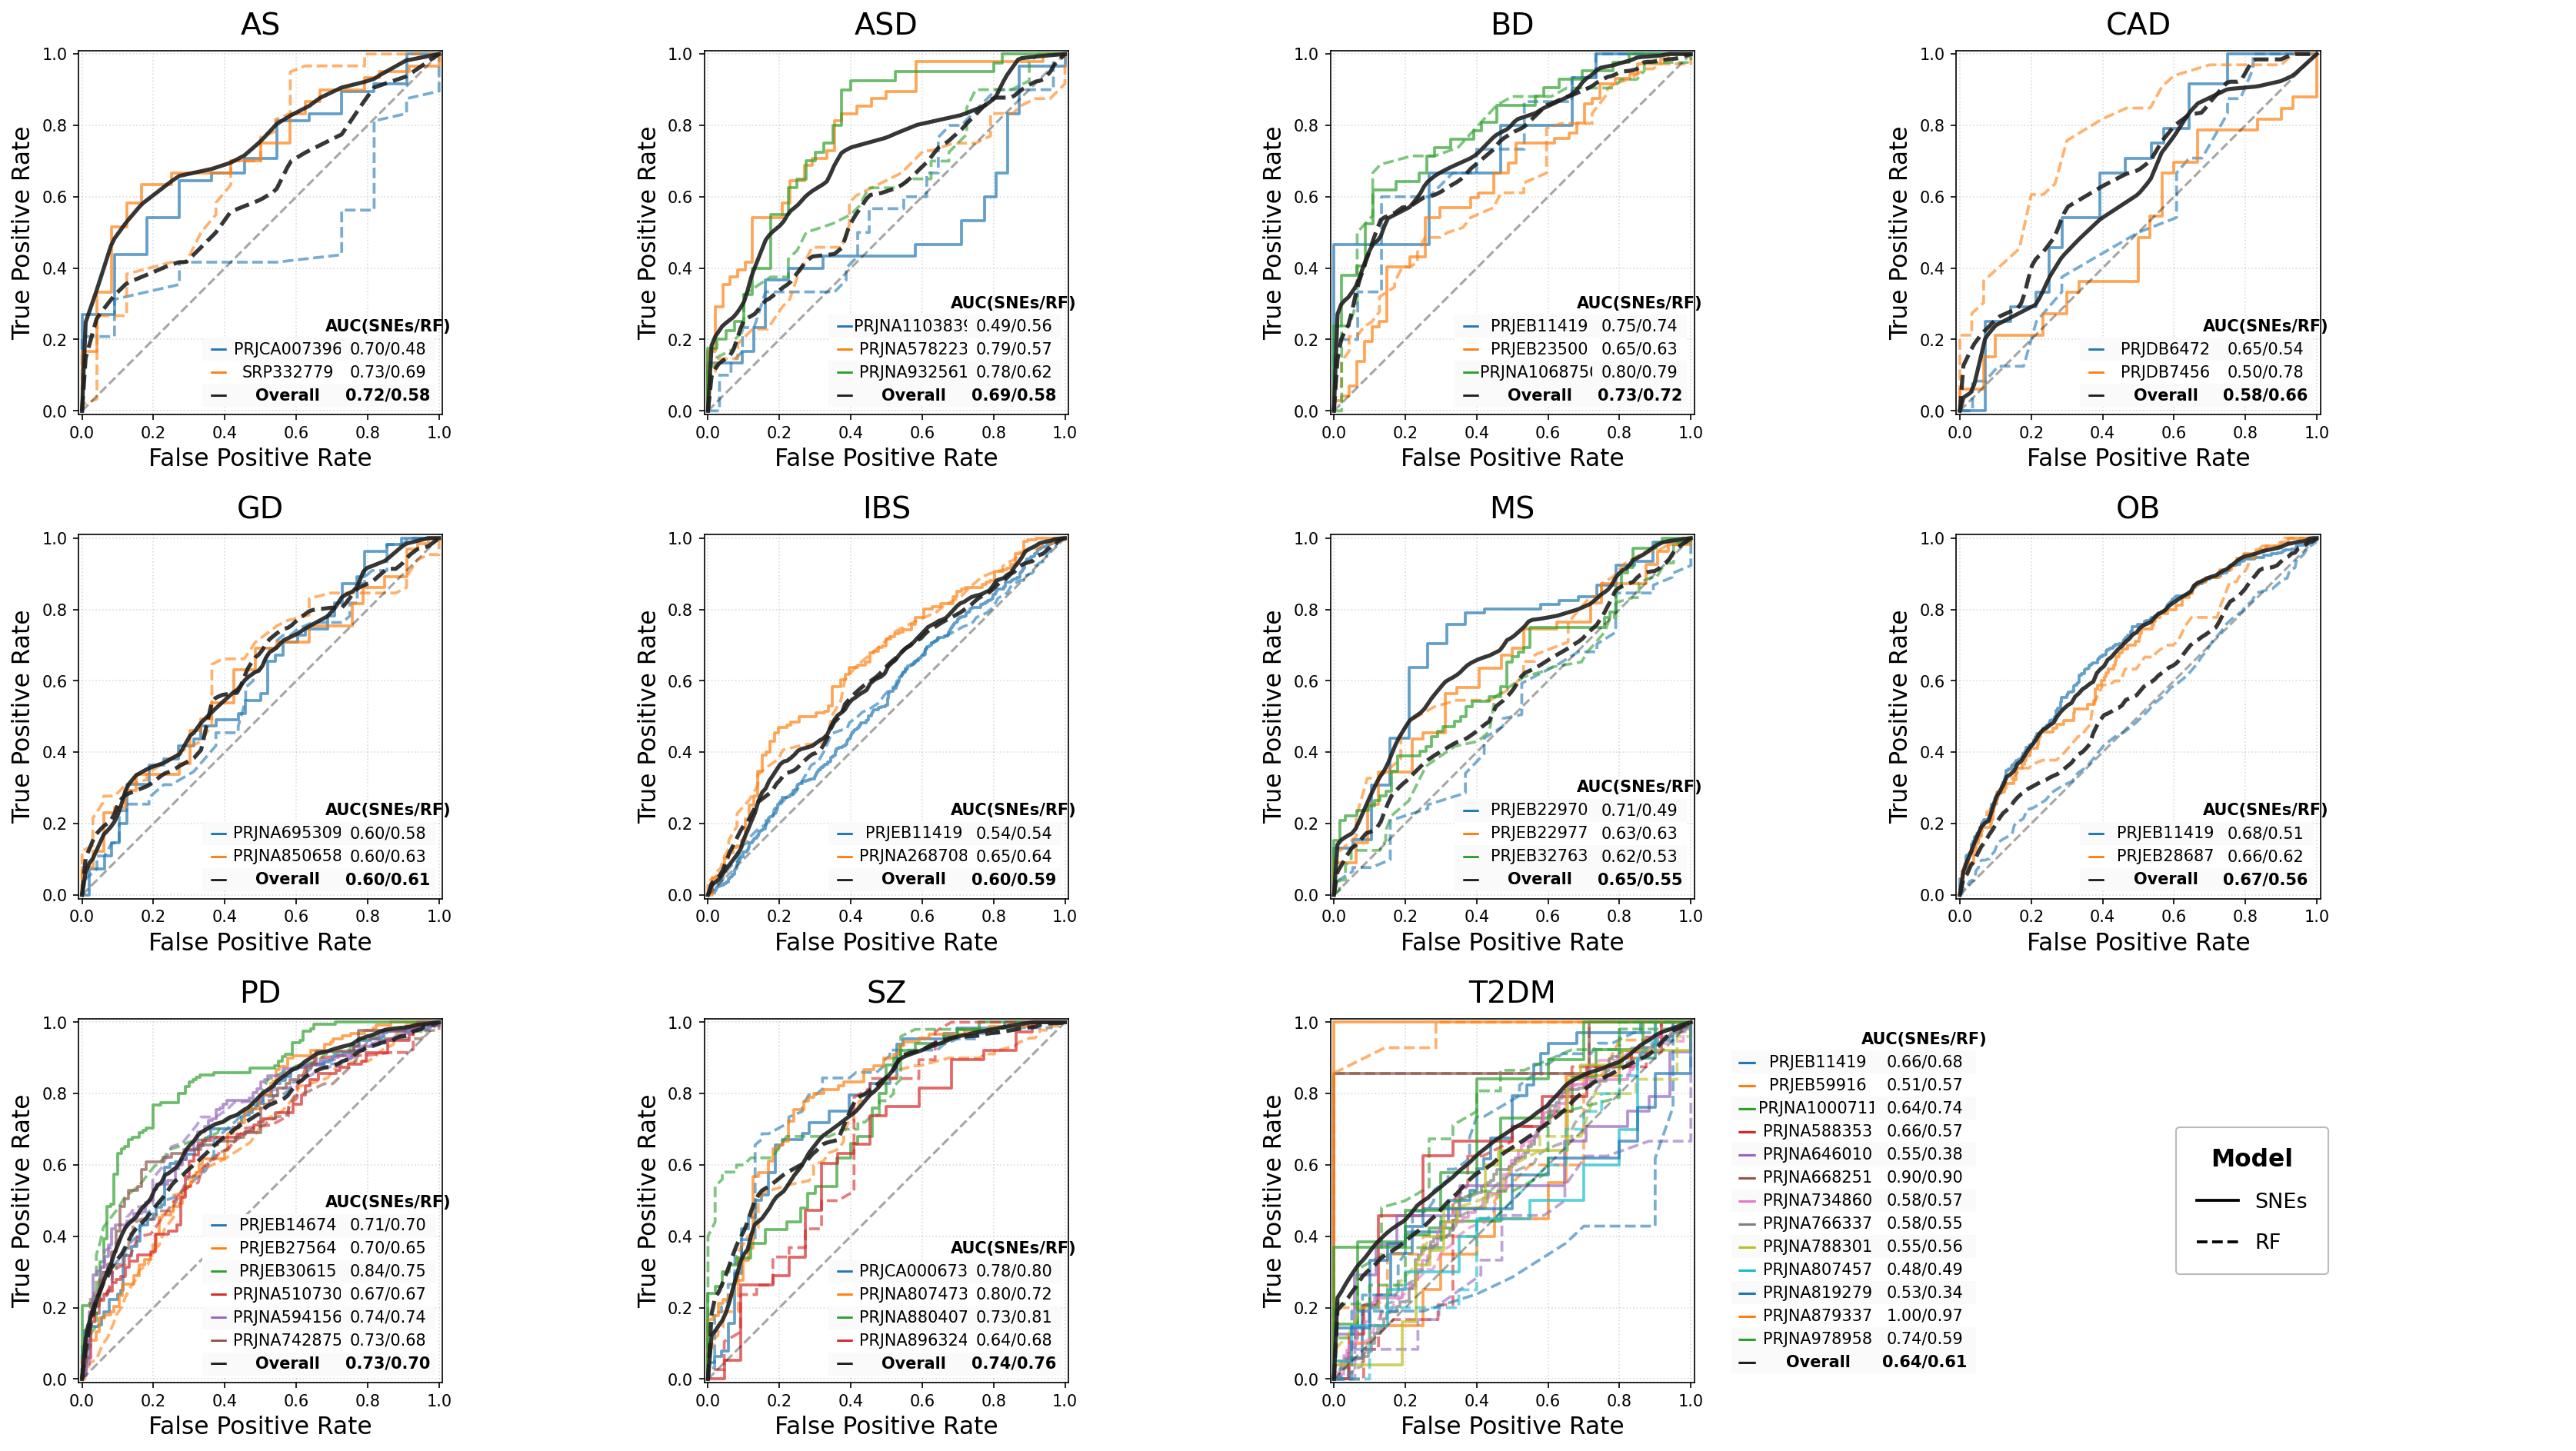

In [32]:
# --------------------------------------------------------------------------- #
# Configuration  --  edit this block
# --------------------------------------------------------------------------- #
RESULT_BASE = Path("Data/disease_data")
FIGURE_DIR = Path("Figures")
OUTPUT_NAME = "diseases_roc_plot_SNEs_vs_RF"      # saved as .pdf and .png

RUN_LIST_PATH = "run_leave_one_study_out_each_diease_list.tsv"
DISEASE_COL, STUDY_COL = 0, 1                     # column positions in run_list
DISEASE_COL_NAME, STUDY_COL_NAME = "disease_name_ab", "study"

DISEASES_TO_PLOT = ["AS", "ASD", "BD", "CAD",
                    "GD", "IBS", "MS", "OB",
                    "PD", "SZ", "T2DM"]

DISEASE_ALIAS = {"IBD_feces": "IBD"}              # applied only to the title

# Where each method's predictions live below <RESULT_BASE>/<dir>/<disease>_<study>/,
# and how several files for one study become one score per sample.
#
#   SNEs  the leave-one-study-out run -- one member per training cohort --
#         combined by 'ens_prob', the mean of the members' probabilities.
#         `dir` must match the --run-name the run was launched with.
#   RF    unchanged: the retrain predictions.
#
# glob: patterns tried in order; the first that finds anything wins. Two are
#       needed because the member directory was called "inner" before it was
#       called "members", and folds run under the older layout still carry the
#       old name. Which one a fold matched is printed, because the layouts came
#       from different versions of the runner and a fold that matched the old
#       one was not necessarily produced by the same protocol as its neighbours.
# agg:  "mean"  average the probabilities of every file found (ens_prob)
#       "first" use the first file only, which is what this script did before
METHOD_SPEC = {
    "SNEs": dict(dir="results_with_SNEs",
                 glob=("members/*/pred_test.csv", "inner/*/pred_test.csv"),
                 agg="mean"),
    "RF":   dict(dir="_results_with_rf",
                 glob=("rf/pred_test.csv",),
                 agg="first"),
}
METHOD_ORDER = ["SNEs", "RF"]
METHOD_STYLE = {"SNEs": "-", "RF": "--"}

# A fold whose members nearly all failed leaves an "ensemble" of one, which is
# a different quantity from the other folds' and is worth seeing rather than
# quietly averaging in.
MIN_MEMBERS_WARN = 2

PLOTS_PER_ROW = 4
WIDTH_PER_CELL = 7.0                              # inches, one disease cell
HEIGHT_PER_ROW = 5.0

SHOW_COUNTS = False        # add a Ctrl/Case column to the table
MAX_INPLOT_ROWS = 7        # more studies than this -> table moves outside the axes
FORCE_EXTERNAL_TABLE = []  # e.g. ["T2DM"] to always put that table outside

# --------------------------------------------------------------------------- #
# Style
# --------------------------------------------------------------------------- #
plt.rcParams["axes.unicode_minus"] = False
plt.rcParams["font.family"] = "sans-serif"
plt.rcParams["font.sans-serif"] = ["DejaVu Sans"]
plt.rcParams["pdf.fonttype"] = 42
plt.rcParams["ps.fonttype"] = 42

study_line_linewidth = 1.8
study_line_alpha = {"SNEs": 0.70, "RF": 0.60}
mean_line_color = "#202020"
mean_line_linewidth = 2.5
mean_line_alpha = {"SNEs": 0.90, "RF": 0.90}
mean_line_zorder = 10

row_color_even = "#FAFAFA"
row_color_odd = "#FFFFFF"

FPR_COMMON = np.linspace(0, 1, 100)


# --------------------------------------------------------------------------- #
# Helpers
# --------------------------------------------------------------------------- #
def get_tab10_colors(n):
    cmap = plt.get_cmap("tab10")
    if n <= 0:
        return []
    return [cmap(i % cmap.N) for i in range(n)]


def load_run_list():
    """Return a DataFrame with the disease/study pairs.

    The separator follows the extension: a .tsv read with the comma default
    lands every column in one, and the failure shows up much later as "no
    predictions for ..." rather than as a parse error.
    """
    if RUN_LIST_PATH is None:
        rl = globals().get("run_list")
        if rl is None:
            raise RuntimeError("RUN_LIST_PATH is None and no `run_list` is defined.")
        return rl
    sep = "\t" if str(RUN_LIST_PATH).lower().endswith((".tsv", ".tab", ".txt")) else ","
    rl = pd.read_csv(RUN_LIST_PATH, sep=sep)
    if rl.shape[1] == 1:
        raise RuntimeError(
            f"{RUN_LIST_PATH} parsed into a single column with sep={sep!r}; "
            f"the separator is wrong. First column name: {rl.columns[0]!r}")
    return rl


def get_pair(run_list, i):
    """Return (disease, study) for row i, by name if available else by position."""
    row = run_list.iloc[i]
    if DISEASE_COL_NAME in run_list.columns and STUDY_COL_NAME in run_list.columns:
        return str(row[DISEASE_COL_NAME]), str(row[STUDY_COL_NAME])
    return str(row.iloc[DISEASE_COL]), str(row.iloc[STUDY_COL])


def load_prediction(method, disease, study):
    """One score per sample for this method/disease/study, or None.

    Under agg="mean" this is ens_prob: the members' probabilities averaged
    after being aligned on sample_id. Aligning on the id rather than on row
    order is the difference between an ensemble and a silently shuffled one --
    the members are written by separate processes and nothing in the pipeline
    promises the same order.

    The number of files that went into the score, and which layout they came
    from, are attached to ``pred.attrs`` so the caller can say how large each
    fold's ensemble actually was and where it came from.
    """
    spec = METHOD_SPEC[method]
    fold_dir = RESULT_BASE / spec["dir"] / f"{disease}_{study}"
    patterns = spec["glob"]
    if isinstance(patterns, str):
        patterns = (patterns,)

    hits = {pat: sorted(fold_dir.glob(pat)) for pat in patterns}
    matched = [pat for pat in patterns if hits[pat]]
    if not matched:
        return None
    if len(matched) > 1:
        # Two layouts side by side means two runs wrote into the same fold. The
        # first pattern wins, but say so: silently preferring one run's members
        # over another's is how a figure ends up mixing protocols.
        print(f"  [warn] {method}/{disease}_{study}: predictions under both "
              + " and ".join(repr(p.split('/')[0]) for p in matched)
              + f"; using {matched[0].split('/')[0]!r}")
    layout = matched[0].split("/")[0]
    file_list = hits[matched[0]]

    if spec["agg"] == "first":
        pred = pd.read_csv(file_list[0])
        pred.attrs["n_files"] = 1
        pred.attrs["n_found"] = len(file_list)
        pred.attrs["layout"] = layout
        return pred

    frames = {}
    for path in file_list:
        d = pd.read_csv(path)
        d["sample_id"] = d["sample_id"].astype(str)
        frames[path.parent.name] = d.set_index("sample_id")[["true_label", "prob"]]

    names = list(frames)
    base = frames[names[0]]
    probs = []
    for name in names:
        d = frames[name]
        s = d["prob"].reindex(base.index)
        if s.isna().any():
            raise ValueError(
                f"{method}/{disease}_{study}: member {name!r} is missing "
                f"{int(s.isna().sum())} of {len(base)} samples, so the members "
                f"did not all score the same test table")
        if not (d["true_label"].reindex(base.index) == base["true_label"]).all():
            raise ValueError(
                f"{method}/{disease}_{study}: member {name!r} disagrees with "
                f"{names[0]!r} about the labels")
        probs.append(s.to_numpy())

    pred = pd.DataFrame({"sample_id": base.index.to_numpy(),
                         "true_label": base["true_label"].to_numpy(),
                         "prob": np.mean(probs, axis=0)})
    pred.attrs["n_files"] = len(probs)
    pred.attrs["n_found"] = len(file_list)
    pred.attrs["layout"] = layout
    return pred


def roc_from_prediction(pred):
    y_true = pred["true_label"].values
    y_score = pred["prob"].values
    fpr, tpr, _ = roc_curve(y_true, y_score)
    return fpr, tpr, roc_auc_score(y_true, y_score)


def count_labels(pred):
    y_true = pd.Series(pred["true_label"].values)
    return int((y_true == 0).sum()), int((y_true == 1).sum())


def interp_tpr(fpr, tpr):
    """Interpolate one ROC curve onto FPR_COMMON (duplicate FPRs collapsed)."""
    curve = (pd.DataFrame({"FPR": fpr, "TPR": tpr})
             .groupby("FPR", as_index=False)["TPR"].max()
             .sort_values("FPR"))
    return np.interp(FPR_COMMON, curve["FPR"].values, curve["TPR"].values)


# --------------------------------------------------------------------------- #
# Collect results
# --------------------------------------------------------------------------- #
run_list_df = load_run_list()

records = {}          # disease -> list of per-study dicts
seen_pairs = set()
thin_folds = []       # folds whose SNEs ensemble came from too few members

print(f"{'fold':<34}" + "".join(f"{m + ' (layout, n, AUC)':>30}"
                                for m in METHOD_ORDER))
print("-" * (34 + 30 * len(METHOD_ORDER)))

for i in range(run_list_df.shape[0]):
    disease, study = get_pair(run_list_df, i)

    if DISEASES_TO_PLOT is not None and disease not in DISEASES_TO_PLOT:
        continue
    if (disease, study) in seen_pairs:
        continue
    seen_pairs.add((disease, study))

    entry = {"study": study, "curves": {}, "aucs": {}, "n_files": {},
             "layout": {}, "n_ctrl": None, "n_case": None, "status": "ok"}

    for method in METHOD_ORDER:
        pred = load_prediction(method, disease, study)
        if pred is None:
            print(f"Warning: no predictions for {method} / {disease} / {study} "
                  f"({RESULT_BASE / METHOD_SPEC[method]['dir'] / f'{disease}_{study}'}"
                  f"/{METHOD_SPEC[method]['glob']})")
            entry["status"] = "missing"
            continue
        try:
            fpr, tpr, auc_val = roc_from_prediction(pred)
        except Exception as exc:            # e.g. a single-class test split
            print(f"Error computing ROC for {method} / {disease} / {study}: {exc}")
            entry["status"] = "error"
            continue
        entry["curves"][method] = (fpr, tpr)
        entry["aucs"][method] = auc_val
        entry["n_files"][method] = pred.attrs.get("n_files", 1)
        entry["layout"][method] = pred.attrs.get("layout", "?")
        if entry["n_ctrl"] is None:
            entry["n_ctrl"], entry["n_case"] = count_labels(pred)

    if entry["status"] == "ok":
        print(f"{disease + '_' + study:<34}"
              + "".join(f"{entry['layout'].get(m, '?'):>12}, "
                        f"{entry['n_files'].get(m, 0):>3}, "
                        f"{entry['aucs'].get(m, float('nan')):>11.4f}"
                        for m in METHOD_ORDER))
        n_sne = entry["n_files"].get("SNEs", 0)
        if METHOD_SPEC["SNEs"]["agg"] == "mean" and n_sne < MIN_MEMBERS_WARN:
            thin_folds.append(f"{disease}_{study}(n={n_sne})")

    records.setdefault(disease, []).append(entry)

layouts_seen = {}
for dis, es in records.items():
    for e in es:
        for m, lay in e.get("layout", {}).items():
            layouts_seen.setdefault(m, set()).add(lay)
for m, lays in layouts_seen.items():
    if len(lays) > 1:
        print(f"\nWarning: {m} predictions came from more than one directory "
              f"layout ({', '.join(sorted(lays))}). Those layouts belong to "
              f"different versions of the runner, so check that the folds "
              f"really were produced by the same protocol -- read `inner_mode` "
              f"out of a result.json under each.")

if thin_folds:
    print(f"\nWarning: {len(thin_folds)} fold(s) have fewer than "
          f"{MIN_MEMBERS_WARN} SNEs members, so their curve is a single model "
          f"rather than an ensemble and is not comparable with the rest: "
          + ", ".join(thin_folds))

# Keep the order requested in DISEASES_TO_PLOT
if DISEASES_TO_PLOT is None:
    diseases_ordered = sorted(records.keys())
else:
    diseases_ordered = [d for d in DISEASES_TO_PLOT if d in records]
    missing = [d for d in DISEASES_TO_PLOT if d not in records]
    if missing:
        print(f"Warning: no data found for: {', '.join(missing)} (skipped)")

num_diseases = len(diseases_ordered)
if num_diseases == 0:
    raise SystemExit("Nothing to plot: no disease matched the configuration.")


# --------------------------------------------------------------------------- #
# Figure skeleton
# --------------------------------------------------------------------------- #
n_rows = math.ceil(num_diseases / PLOTS_PER_ROW)
n_cols = min(PLOTS_PER_ROW, num_diseases)

fig = plt.figure(figsize=(n_cols * WIDTH_PER_CELL, n_rows * HEIGHT_PER_ROW), dpi=150)
gs_main = gridspec.GridSpec(n_rows, n_cols, figure=fig, wspace=0.00, hspace=0.33)

auc_summary = []          # collected for the csv export


# --------------------------------------------------------------------------- #
# One cell per disease
# --------------------------------------------------------------------------- #
for plot_idx, disease in enumerate(diseases_ordered):
    entries = sorted(records[disease], key=lambda e: e["study"])
    colors = get_tab10_colors(len(entries))

    r, c = divmod(plot_idx, PLOTS_PER_ROW)
    gs_cell = gridspec.GridSpecFromSubplotSpec(
        1, 2, subplot_spec=gs_main[r, c], width_ratios=[2.8, 1.2], wspace=0.20)

    ax_roc = fig.add_subplot(gs_cell[0, 0])
    ax_side = fig.add_subplot(gs_cell[0, 1])
    ax_side.axis("off")

    interp_store = {m: [] for m in METHOD_ORDER}
    aucs_for_mean = {m: [] for m in METHOD_ORDER}
    total_ctrl, total_case = 0, 0
    table_rows = []

    # ---- study curves ---------------------------------------------------- #
    for row_idx, entry in enumerate(entries):
        color = colors[row_idx]
        study = entry["study"]

        for method in METHOD_ORDER:
            if method not in entry["curves"]:
                continue
            fpr, tpr = entry["curves"][method]
            ax_roc.plot(fpr, tpr, color=color, linestyle=METHOD_STYLE[method],
                        linewidth=study_line_linewidth,
                        alpha=study_line_alpha[method])
            interp_store[method].append(interp_tpr(fpr, tpr))
            aucs_for_mean[method].append(entry["aucs"][method])

        if entry["n_ctrl"] is not None:
            counts_text = f"{entry['n_ctrl']}/{entry['n_case']}"
            total_ctrl += entry["n_ctrl"]
            total_case += entry["n_case"]
        else:
            counts_text = "N/A"

        if len(entry["aucs"]) == len(METHOD_ORDER):
            auc_text = "/".join(f"{entry['aucs'][m]:.2f}" for m in METHOD_ORDER)
            name = study
        else:
            auc_text = "N/A"
            name = f"{study} ({'Miss' if entry['status'] == 'missing' else 'Err'})"

        table_rows.append({"color": color if auc_text != "N/A" else "grey",
                           "name": name, "auc_text": auc_text,
                           "counts": counts_text, "is_mean": False,
                           "row_idx": row_idx})

        auc_summary.append({"disease": disease, "study": study,
                            **{f"AUC_{m}": entry["aucs"].get(m, np.nan)
                               for m in METHOD_ORDER},
                            **{f"n_files_{m}": entry["n_files"].get(m, 0)
                               for m in METHOD_ORDER},
                            **{f"layout_{m}": entry["layout"].get(m, "")
                               for m in METHOD_ORDER},
                            "n_ctrl": entry["n_ctrl"], "n_case": entry["n_case"]})

    # ---- mean curves ----------------------------------------------------- #
    if all(len(interp_store[m]) > 0 for m in METHOD_ORDER):
        for method in METHOD_ORDER:
            mean_tpr = np.mean(interp_store[method], axis=0)
            mean_tpr[0], mean_tpr[-1] = 0.0, 1.0
            ax_roc.plot(FPR_COMMON, mean_tpr, color=mean_line_color,
                        linestyle=METHOD_STYLE[method],
                        linewidth=mean_line_linewidth,
                        alpha=mean_line_alpha[method], zorder=mean_line_zorder)

        mean_auc_text = "/".join(f"{np.mean(aucs_for_mean[m]):.2f}" for m in METHOD_ORDER)
        table_rows.append({"color": mean_line_color, "name": "Overall",
                           "auc_text": mean_auc_text,
                           "counts": f"{total_ctrl}/{total_case}",
                           "is_mean": True, "row_idx": len(entries)})

        auc_summary.append({"disease": disease, "study": "Overall",
                            **{f"AUC_{m}": np.mean(aucs_for_mean[m])
                               for m in METHOD_ORDER},
                            **{f"n_files_{m}": np.nan for m in METHOD_ORDER},
                            **{f"layout_{m}": "" for m in METHOD_ORDER},
                            "n_ctrl": total_ctrl, "n_case": total_case})

    # ---- ROC cosmetics --------------------------------------------------- #
    ax_roc.plot([0, 1], [0, 1], "k--", alpha=0.35, zorder=5)
    ax_roc.set_xlim([-0.01, 1.01])
    ax_roc.set_ylim([-0.01, 1.01])
    ticks = np.arange(0, 1.01, 0.2)
    ax_roc.set_xticks(ticks)
    ax_roc.set_yticks(ticks)
    ax_roc.set_aspect("equal", adjustable="box")
    ax_roc.set_title(DISEASE_ALIAS.get(disease, disease), fontsize=19, pad=10)
    ax_roc.set_xlabel("False Positive Rate", fontsize=15)
    ax_roc.set_ylabel("True Positive Rate", fontsize=15)
    ax_roc.grid(True, linestyle=":", alpha=0.45, zorder=1)
    ax_roc.tick_params(axis="both", which="major", labelsize=10)

    # ---- table ----------------------------------------------------------- #
    if not table_rows:
        continue

    external = (disease in FORCE_EXTERNAL_TABLE) or (len(table_rows) > MAX_INPLOT_ROWS)

    if external:
        target_ax = ax_side
        table_loc = "center"
        fontsize = 10
        col_widths = [0.18, 0.65, 0.60] + ([0.45] if SHOW_COUNTS else [])
        scale_y = 1.2
        dash_bump = 2
    else:
        target_ax = ax_roc
        table_loc = "lower right"
        fontsize = 10
        col_widths = [0.09, 0.29, 0.26] + ([0.20] if SHOW_COUNTS else [])
        scale_y = 1.2
        dash_bump = 1

    auc_header = f"AUC({'/'.join(METHOD_ORDER)})"
    col_labels = [" ", " ", auc_header] + (["Ctrl/Case"] if SHOW_COUNTS else [])
    cell_text = [["—", r_["name"], r_["auc_text"]]
                 + ([r_["counts"]] if SHOW_COUNTS else [])
                 for r_ in table_rows]

    the_table = target_ax.table(cellText=cell_text, colLabels=col_labels,
                                loc=table_loc, colWidths=col_widths)
    the_table.auto_set_font_size(False)
    the_table.set_fontsize(fontsize)
    the_table.scale(1, scale_y)

    for (row, col), cell in the_table.get_celld().items():
        cell.set_linewidth(0)
        cell.set_edgecolor("none")
        cell.set_text_props(ha="center", va="center")
        if row == 0:
            cell.set_facecolor("none")
            cell.set_text_props(weight="bold", color="black")
            if col < 2:
                cell.get_text().set_text("")
        else:
            row_data = table_rows[row - 1]
            bg = row_color_even if row_data["row_idx"] % 2 == 0 else row_color_odd
            if row_data["is_mean"]:
                bg = row_color_even
            cell.set_facecolor(bg)

            if col == 0:
                cell.get_text().set_color(row_data["color"])
                cell.get_text().set_weight("bold")
                cell.get_text().set_fontsize(fontsize + dash_bump)
            if row_data["is_mean"] and col > 0:
                cell.set_text_props(weight="bold")

    if not external:
        the_table.set_zorder(20)


# --------------------------------------------------------------------------- #
# Global legend in the first unused cell
# --------------------------------------------------------------------------- #
legend_elements = [Line2D([0], [0], color="black", lw=1.8,
                          linestyle=METHOD_STYLE[m], label=m) for m in METHOD_ORDER]

free_cells = [(r, c) for r in range(n_rows) for c in range(n_cols)
              if r * n_cols + c >= num_diseases]

if free_cells:
    lr, lc = free_cells[-1]
    ax_legend = fig.add_subplot(gs_main[lr, lc])
    ax_legend.axis("off")
    leg = ax_legend.legend(handles=legend_elements, loc="center", fontsize=13,
                           frameon=True, edgecolor="darkgrey", borderpad=1.0,
                           labelspacing=1.0, title="Model", title_fontsize="15")
    leg.get_title().set_fontweight("bold")
else:
    fig.legend(handles=legend_elements, loc="lower right",
               bbox_to_anchor=(0.98, 0.03), ncol=1, fontsize=11, frameon=True,
               edgecolor="darkgrey", title="Model", title_fontsize="12")


# --------------------------------------------------------------------------- #
# Save
# --------------------------------------------------------------------------- #
try:
    fig.tight_layout(pad=0.5)
except ValueError as exc:
    print(f"tight_layout failed ({exc}); retrying with larger padding.")
    fig.tight_layout(pad=1.0)

FIGURE_DIR.mkdir(parents=True, exist_ok=True)

# for ext in ("pdf", "png"):
#     out_path = FIGURE_DIR / f"{OUTPUT_NAME}.{ext}"
#     try:
#         fig.savefig(out_path, dpi=300, facecolor="white", bbox_inches="tight")
#         print(f"Figure saved: {out_path}")
#     except Exception as exc:
#         print(f"Error saving {out_path}: {exc}")

# if auc_summary:
#     summary_path = FIGURE_DIR / f"{OUTPUT_NAME}_auc_summary.csv"
#     pd.DataFrame(auc_summary).to_csv(summary_path, index=False)
#     print(f"AUC summary saved: {summary_path}")

plt.show()

In [43]:
auc_rf = []
auc_snes = []
auc_dnabert2 = []
auc_phylopca = []
auc_abundancepcoa = []

In [44]:
for i in range(run_list.shape[0]):
    ### rf
    pattern = Path(f"Data/disease_data/_results_rf/{run_list.iloc[i,0]}_{run_list.iloc[i,1]}/retrain")
    file_list = list(pattern.glob("*/pred_test.csv"))
    pred = pd.read_csv(file_list[0])
    auc_rf.append(roc_auc_score(pred['true_label'].values, pred["prob"].values))

    ### snes
    pattern = Path(f"Data/disease_data/results_with_SNEs/{run_list.iloc[i,0]}_{run_list.iloc[i,1]}/retrain")
    file_list = list(pattern.glob("*/pred_test.csv"))
    pred = pd.read_csv(file_list[0])
    auc_snes.append(roc_auc_score(pred['true_label'].values, pred["prob"].values))

    ### dnabert2
    pattern = Path(f"Data/disease_data/results_with_dnabert2/{run_list.iloc[i,0]}_{run_list.iloc[i,1]}/retrain")
    file_list = list(pattern.glob("*/pred_test.csv"))
    pred = pd.read_csv(file_list[0])
    auc_dnabert2.append(roc_auc_score(pred['true_label'].values, pred["prob"].values))

    ### phylopcoa
    # pattern = Path(f"Data/disease_data/results_with_phylo_embed_PCAA/{run_list.iloc[i,0]}_{run_list.iloc[i,1]}/retrain")
    # file_list = list(pattern.glob("*/pred_test.csv"))
    # pred = pd.read_csv(file_list[0])
    # auc_phylopca.append(roc_auc_score(pred['true_label'].values, pred["prob"].values))

    ### auc_abundancepcoa
    pattern = Path(f"Data/disease_data/results_with_pretain_df_reduced_PCA/{run_list.iloc[i,0]}_{run_list.iloc[i,1]}/retrain")
    file_list = list(pattern.glob("*/pred_test.csv"))
    pred = pd.read_csv(file_list[0])
    auc_abundancepcoa.append(roc_auc_score(pred['true_label'].values, pred["prob"].values))

In [48]:
auc_res = run_list.copy()
auc_res["auc_rf"] = auc_rf
auc_res["auc_snes"] = auc_snes
auc_res["auc_dnabert2"] = auc_dnabert2
# auc_res["auc_phylopca"] = auc_phylopcoa
auc_res["auc_abundancepcoa"] = auc_abundancepcoa

In [50]:
auc_res.head()

,disease,study,auc_rf,auc_snes,auc_dnabert2,auc_abundancepcoa
0,AS,PRJCA007396,0.571023,0.630682,0.598485,0.537879
1,AS,SRP332779,0.703819,0.614583,0.679167,0.643056
2,ASD,PRJNA1103839,0.550538,0.513978,0.541935,0.590323
3,ASD,PRJNA578223,0.564453,0.652778,0.467448,0.564670
4,ASD,PRJNA932561,0.594375,0.818750,0.620000,0.623125


In [105]:
metadata_ASD = metadata.loc[metadata.disease_name_ab == "ASD"]

In [107]:
metadata_ASD.study.unique()

array(['PRJNA932561', 'PRJNA1103839', 'PRJNA578223'], dtype=object)

In [111]:
metadata_ASD.loc[metadata_ASD["sample"] == "SRR28782202"]

,sample,study,diagnosis,group,age,sex,bmi,country,region,pcr_primers,platform,disease_name,title,disease_name_ab,host_body_mass_index,site,subject_id
7627,SRR28782202,PRJNA1103839,healthy,0.0,NaN,NaN,NaN,Mexico: Mexico City,V3-V4,NaN,Illumina MiSeq,Autism Spectrum Disorder,NaN,ASD,NaN,NaN,NaN


In [112]:
metadata_ASD.groupby(["study", "group"])["sample"].count()

study         group
PRJNA1103839  0.0      31
              1.0      30
PRJNA578223   0.0      48
              1.0      48
PRJNA932561   0.0      40
              1.0      40
Name: sample, dtype: int64